C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24636\2408557062.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hotel_star_rating', palette='magma')
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24636\2408557062.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='hotel_star_rating', y='city_population', estimator=np.mean, palette='Blues_d')
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24636\2408557062.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='hot

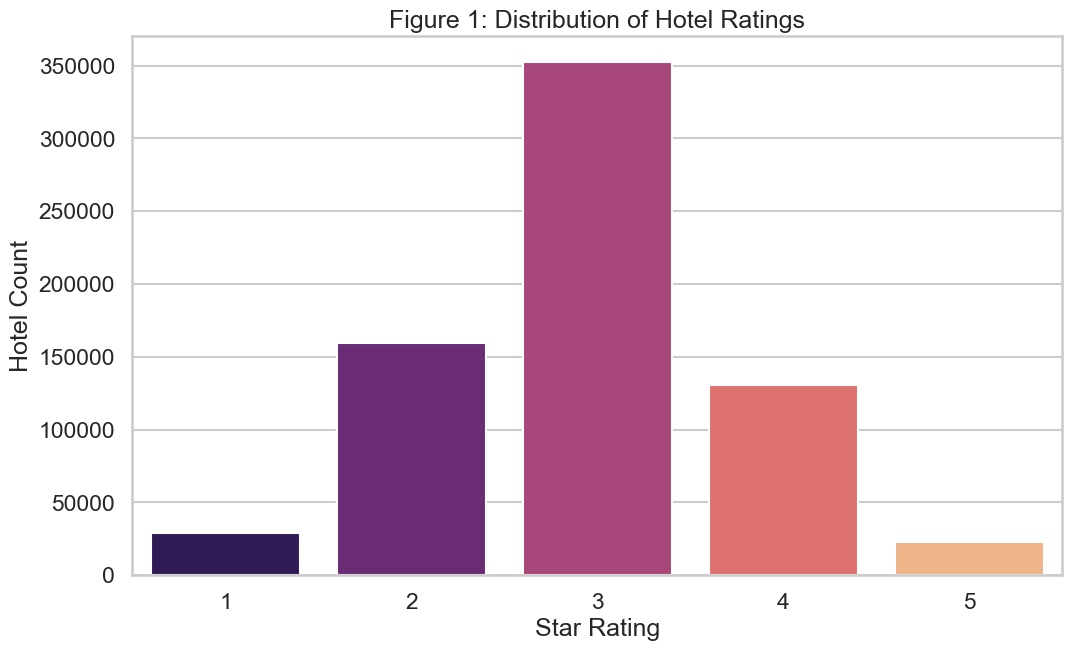

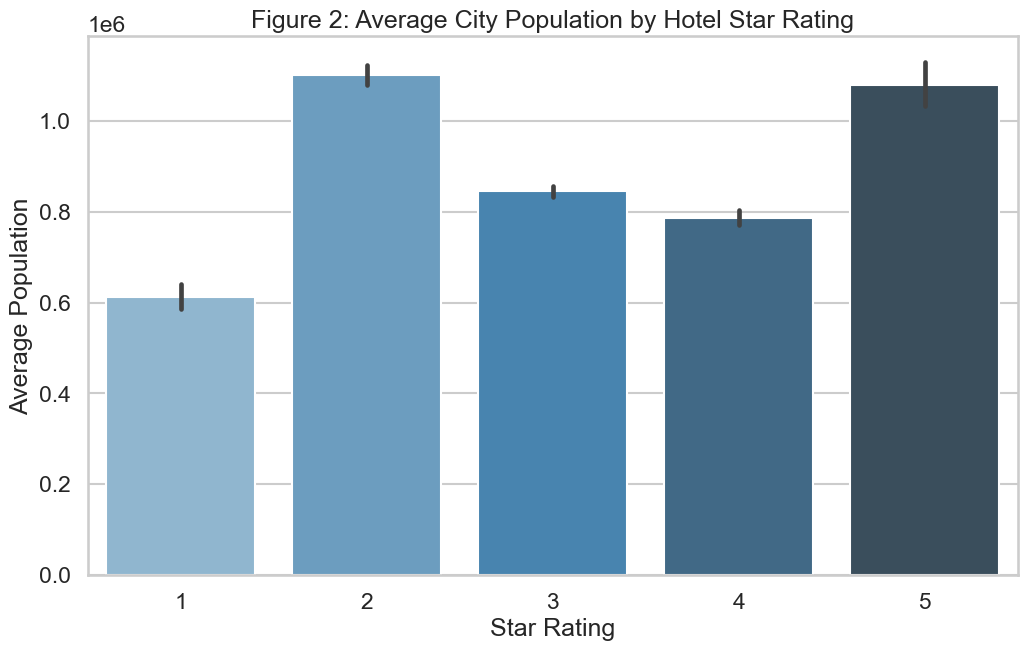

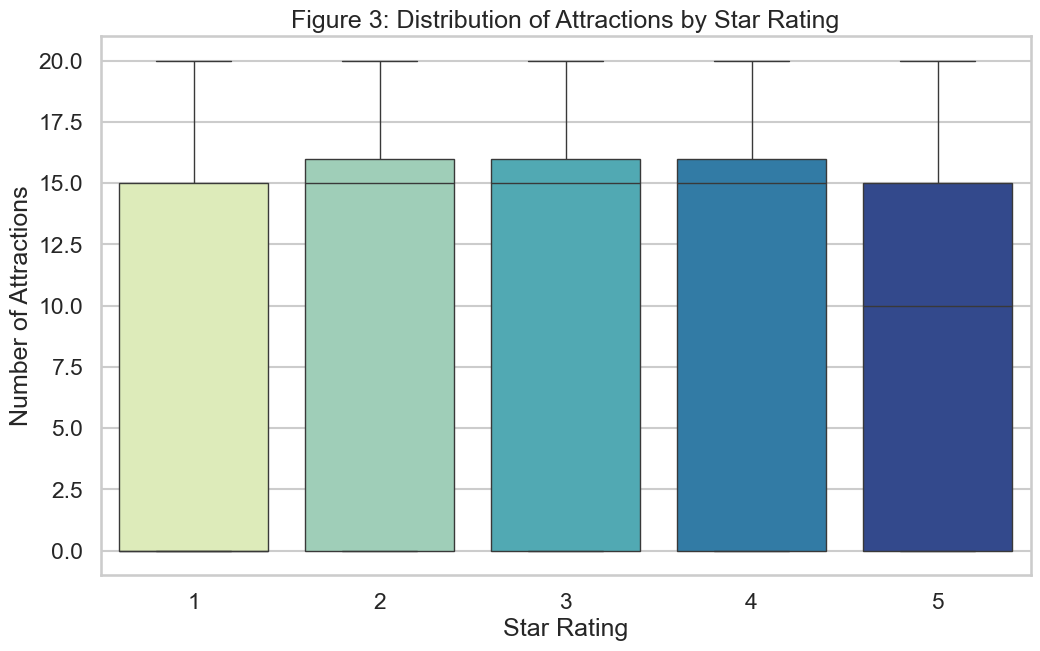

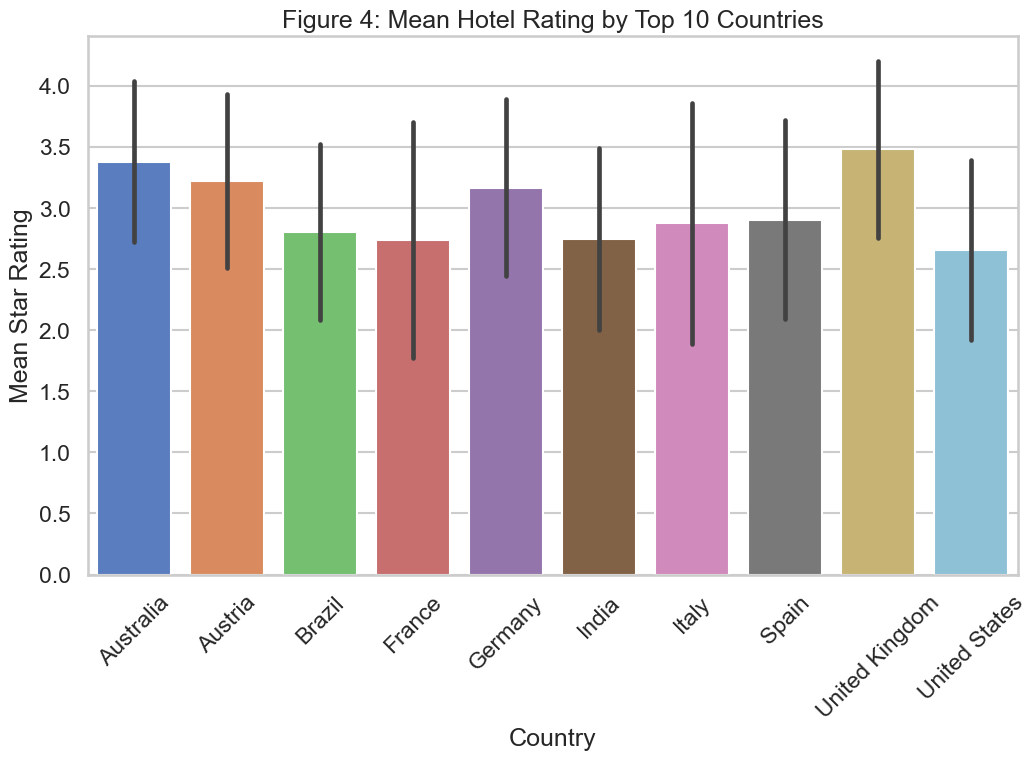

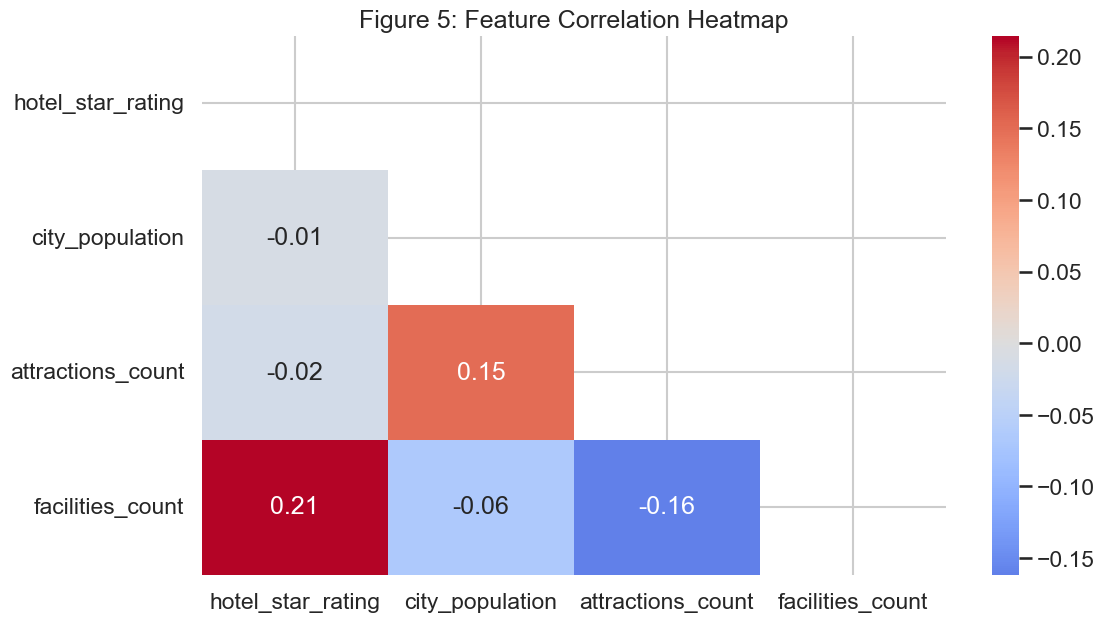

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data using your project directory structure
df = pd.read_parquet('../../data/processed/hotels_with_cities.parquet')

# Global styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --- 1. Distribution of Hotel Ratings ---
plt.figure()
sns.countplot(data=df, x='hotel_star_rating', palette='magma')
plt.title('Figure 1: Distribution of Hotel Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Hotel Count')
plt.savefig('eda_1_rating_imbalance.png')

# --- 2. Rating vs Population ---
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='city_population', estimator=np.mean, palette='Blues_d')
plt.title('Figure 2: Average City Population by Hotel Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Population')
plt.savefig('eda_2_rating_vs_pop.png')

# --- 3. Rating vs Attractions Count (NEW FORMAT: Boxplot) ---
plt.figure()
# Boxplots clearly show the median, quartiles, and outliers for each rating tier
sns.boxplot(data=df, x='hotel_star_rating', y='attractions_count', palette='YlGnBu')
plt.title('Figure 3: Distribution of Attractions by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Number of Attractions')
plt.savefig('eda_3_rating_vs_attractions.png')

# --- 4. Rating by Country ---
top_countries = df['countyName'].value_counts().nlargest(10).index
plt.figure()
df_top = df[df['countyName'].isin(top_countries)]
sns.barplot(data=df_top, x='countyName', y='hotel_star_rating', errorbar='sd', palette='muted')
plt.xticks(rotation=45)
plt.title('Figure 4: Mean Hotel Rating by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Mean Star Rating')
plt.savefig('eda_4_rating_by_country.png')

# --- 5. Correlation Heatmap ---
plt.figure()
numeric_cols = ['hotel_star_rating', 'city_population', 'attractions_count', 'facilities_count']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Figure 5: Feature Correlation Heatmap')
plt.savefig('eda_5_heatmap.png')

plt.show()